# Analisis Pola Musiman

## Metodologi

1. Memuat data hasil agregasi dari PostgreSQL.
2. Memvisualisasikan data.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('data/superstore_monthly_sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')

## Visualisasi Pola Musiman

Memvisualisasikan penjualan bulanan untuk mengidentifikasi pola musiman antar tahun.

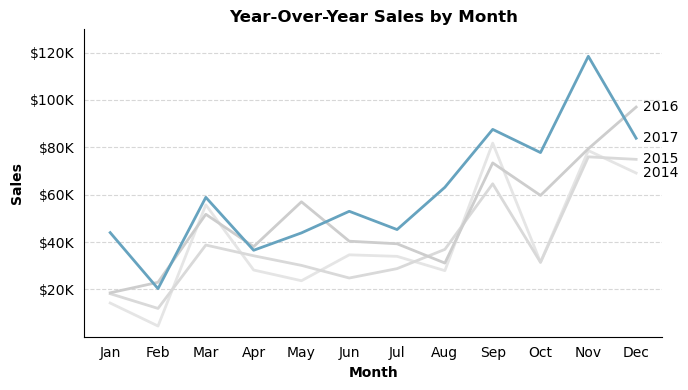

In [2]:
plt.figure(figsize=(7,4))
palette = ['#e5e5e5', '#d9d9d9', '#cdcdcd', '#66A3BF']
sns.lineplot(data=df, x='order_month', y='sales', hue='order_year', ls='-', lw=2, palette=palette, alpha=1)

title_dict = {'family':plt.rcParams['font.family'],
              'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':5,
              'alpha':1}

label_dict = {'x':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'alpha':1}, 
              
              'y':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1}}

plt.title('Year-Over-Year Sales by Month', **title_dict)
plt.xlabel('Month', **label_dict['x'])
plt.ylabel('Sales', **label_dict['y'])

ax = plt.gca()
ax.tick_params(which='major', axis='both', left=False, bottom=False)
ax.set_xticks(ticks=ax.get_xticks(), labels=df['order_month'].map(lambda x: x[:3]).unique())
ax.set_yticks(ticks=ax.get_yticks()[2:-1])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1_000:.0f}K'))
ax.set_ylim(0, 130_000)

x = ax.get_xticks().max() + 0.15
y = df.loc[df['order_month'] == 'December', 'sales'].values
s = df['order_year'].astype(str).unique()

for i in range(len(s)):
    plt.text(x=x, y=y[i], s=s[i], size=10, weight='normal', color='black', ha='left', va='center')

plt.legend().set_visible(False)
plt.grid(which='major', axis='y', ls='--', alpha=0.5)
plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()